# End-to-End Bayesian Tuning - Full 5-Phase Pipeline

This notebook performs Bayesian hyperparameter optimization on the entire 5-stage hierarchical classification pipeline using Optuna's TPE sampler.

The key questions we seek to answer are whether the first four stages benefit from having independent parameters per stage rather than shared parameters, and whether a majority-vote ensemble of three LinearSVC models with different regularization strengths can outperform a single classifier.

For Stage 5, we adopt the best ensemble configuration identified by a dedicated LOOCV-based optimization process, loaded only once at startup from the ensemble results file

Understanding whether these architectural choices yield measurable improvements over the simpler baseline configuration with shared parameters is essential for determining the final pipeline configuration that will be submitted to the competition.

## 0. IMPORTS

From section 0 to 3 is the same of the main.ipynb

In [9]:
import os, random, warnings, json, time
from datetime import timedelta
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.sparse import hstack, csr_matrix

from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 359956
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

## 1. DATA & PREPROCESSING

In [10]:
for res in ["punkt", "punkt_tab", "wordnet", "stopwords",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(res, quiet=True)

df = pd.read_csv("train.csv").dropna(subset=["TEXT", "LABEL"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows")

lemmatizer = WordNetLemmatizer()

def clean_text_none(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("Cleaning texts ")
df["text_clean"] = df["TEXT"].apply(clean_text_none)

print("Extracting stylometric features ")

def extract_stylometric(text):
    text = str(text)
    sentences = sent_tokenize(text)
    n_sentences = max(len(sentences), 1)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    words = word_tokenize(text)
    alpha_words = [w for w in words if w.isalpha()]
    n_words = max(len(alpha_words), 1)
    word_lengths = [len(w) for w in alpha_words] if alpha_words else [0]
    n_chars = max(len(text), 1)
    n_commas = text.count(","); n_periods = text.count(".")
    n_exclaim = text.count("!"); n_question = text.count("?")
    n_semicolon = text.count(";"); n_colon = text.count(":")
    n_dash = text.count("\u2014") + text.count("-")
    n_parens = text.count("(") + text.count(")")
    n_quotes = text.count('"') + text.count("'") + text.count("\u201c") + text.count("\u201d")
    try:
        tags = pos_tag(alpha_words[:200])
        tc = Counter(t for _, t in tags); nt = max(sum(tc.values()), 1)
        pn = (tc.get("NN",0)+tc.get("NNS",0)+tc.get("NNP",0)+tc.get("NNPS",0))/nt
        pv = (tc.get("VB",0)+tc.get("VBD",0)+tc.get("VBG",0)+tc.get("VBN",0)+tc.get("VBP",0)+tc.get("VBZ",0))/nt
        pa = (tc.get("JJ",0)+tc.get("JJR",0)+tc.get("JJS",0))/nt
        pd_ = (tc.get("RB",0)+tc.get("RBR",0)+tc.get("RBS",0))/nt
    except:
        pn = pv = pa = pd_ = 0.0
    uw = set(w.lower() for w in alpha_words); ttr = len(uw)/n_words
    ps = sum(1 for w in alpha_words if len(w)<=3)/n_words
    pl = sum(1 for w in alpha_words if len(w)>=8)/n_words
    return {"n_chars":n_chars,"n_words":n_words,"n_sentences":n_sentences,
        "avg_word_len":np.mean(word_lengths),"std_word_len":np.std(word_lengths),
        "avg_sent_len":np.mean(sent_lengths),
        "std_sent_len":np.std(sent_lengths) if len(sent_lengths)>1 else 0,
        "max_sent_len":max(sent_lengths),"min_sent_len":min(sent_lengths),
        "comma_rate":n_commas/n_words,"period_rate":n_periods/n_words,
        "exclaim_rate":n_exclaim/n_words,"question_rate":n_question/n_words,
        "semicolon_rate":n_semicolon/n_words,"colon_rate":n_colon/n_words,
        "dash_rate":n_dash/n_words,"paren_rate":n_parens/n_words,
        "quote_rate":n_quotes/n_words,
        "total_punct_rate":(n_commas+n_periods+n_exclaim+n_question+n_semicolon+n_colon)/n_words,
        "pct_noun":pn,"pct_verb":pv,"pct_adj":pa,"pct_adv":pd_,
        "noun_verb_ratio":pn/max(pv,0.001),
        "ttr":ttr,"pct_short_words":ps,"pct_long_words":pl,
        "words_per_sentence":n_words/n_sentences,"chars_per_word":n_chars/n_words}

stylo_df = pd.DataFrame(df["TEXT"].apply(extract_stylometric).tolist())
STYLO_ALL = stylo_df.values.astype(float)

STYLO_GROUPS = {
    "all_30": list(range(29)), "punctuation": list(range(9, 19)),
    "pos": list(range(19, 24)), "length": list(range(0, 9)),
    "vocabulary": list(range(24, 27)), "structure": [27, 28],
    "punct_pos": list(range(9, 24)),
    "punct_pos_vocab": list(range(9, 24)) + list(range(24, 27)),
    "no_length": list(range(9, 29)),
    "no_pos": list(range(0, 19)) + list(range(24, 29)),
}

print(f"Stylometric: {STYLO_ALL.shape}")
print("Done.\n")


Loaded 2400 rows
Cleaning texts 
Extracting stylometric features 
Stylometric: (2400, 29)
Done.



## 2. GLOBALS

In [11]:
TEXTS = df["text_clean"].values
LABELS = df["LABEL"].values

N_FOLDS = 5

N_TRIALS = 3580

TUNING_DIR = Path("tuning")
TUNING_DIR.mkdir(exist_ok=True)
CHECKPOINT_FILE = TUNING_DIR / "tuning_checkpoint.json"
RESULTS_FILE = TUNING_DIR / "tuning_results.json"
TOP5_FILE = TUNING_DIR / "tuning_top5_2.json"
DB_FILE = TUNING_DIR / "optuna_study.db"

## 3. FEATURE BUILDERS

In [12]:
def build_impchi(X_tr_text, X_val_text, y_tr, k_per_class,
                 max_feat=15000, ngram_min=1, ngram_max=2, min_df=2, sublinear=True):
    tfidf = TfidfVectorizer(max_features=max_feat, ngram_range=(ngram_min, ngram_max),
                            sublinear_tf=sublinear, min_df=min_df,
                            strip_accents="unicode", analyzer="word")
    X_tr_full = tfidf.fit_transform(X_tr_text)
    X_val_full = tfidf.transform(X_val_text)
    classes = np.unique(y_tr)
    selected = set()
    for cls in classes:
        y_bin = (y_tr == cls).astype(int)
        scores, _ = chi2(X_tr_full, y_bin)
        selected.update(np.argsort(scores)[-k_per_class:])
    sel = sorted(selected)
    return X_tr_full[:, sel], X_val_full[:, sel]


def build_stylo(global_tr_idx, global_val_idx, col_indices):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(STYLO_ALL[global_tr_idx][:, col_indices])
    X_val = scaler.transform(STYLO_ALL[global_val_idx][:, col_indices])
    return csr_matrix(X_tr), csr_matrix(X_val)


## 4. OPTUNA OBJECTIVE

In [13]:
def objective(trial):
    # ══════════════════════════════════════════════════════════
    # A. PHASES 1-4 STRUCTURAL CHOICES
    # ══════════════════════════════════════════════════════════
    phase14_mode = trial.suggest_categorical("p14_mode", ["shared", "per_phase"])
    phase14_voting = trial.suggest_categorical("p14_voting", [True, False])

    # ── TF-IDF (always shared) ──
    tfidf_max_feat = trial.suggest_int("tfidf_max_feat", 3000, 50000, log=True)
    tfidf_ngram_max = trial.suggest_int("tfidf_ngram_max", 1, 3)
    tfidf_sublinear = trial.suggest_categorical("tfidf_sublinear", [True, False])
    tfidf_min_df = trial.suggest_int("tfidf_min_df", 1, 5)

    # ── Model params ──────────────────────────────────────────
    if phase14_mode == "shared":
        svc_C = trial.suggest_float("svc_C", 0.05, 20.0, log=True)
        if phase14_voting:
            svc_C_v2 = trial.suggest_float("svc_C_v2", 0.05, 20.0, log=True)
            svc_C_v3 = trial.suggest_float("svc_C_v3", 0.05, 20.0, log=True)
    else:
        svc_C_1 = trial.suggest_float("svc_C_p1", 0.05, 20.0, log=True)
        svc_C_2 = trial.suggest_float("svc_C_p2", 0.05, 20.0, log=True)
        svc_C_3 = trial.suggest_float("svc_C_p3", 0.05, 20.0, log=True)
        svc_C_4 = trial.suggest_float("svc_C_p4", 0.05, 20.0, log=True)
        if phase14_voting:
            # ── v2: per-phase C for voting models ──
            svc_C_v2_p1 = trial.suggest_float("svc_C_v2_p1", 0.05, 20.0, log=True)
            svc_C_v2_p2 = trial.suggest_float("svc_C_v2_p2", 0.05, 20.0, log=True)
            svc_C_v2_p3 = trial.suggest_float("svc_C_v2_p3", 0.05, 20.0, log=True)
            svc_C_v2_p4 = trial.suggest_float("svc_C_v2_p4", 0.05, 20.0, log=True)
            svc_C_v3_p1 = trial.suggest_float("svc_C_v3_p1", 0.05, 20.0, log=True)
            svc_C_v3_p2 = trial.suggest_float("svc_C_v3_p2", 0.05, 20.0, log=True)
            svc_C_v3_p3 = trial.suggest_float("svc_C_v3_p3", 0.05, 20.0, log=True)
            svc_C_v3_p4 = trial.suggest_float("svc_C_v3_p4", 0.05, 20.0, log=True)

    # ══════════════════════════════════════════════════════════
    # B. PHASE 5 CHOICES
    # ══════════════════════════════════════════════════════════
    p5_voting = trial.suggest_categorical("p5_voting", [True, False])
    p5_model_type = trial.suggest_categorical("p5_model_type", ["histgb", "lightgbm"])
    p5_max_iter = trial.suggest_int("p5_max_iter", 30, 300)
    p5_max_depth = trial.suggest_int("p5_max_depth", 2, 16)
    p5_lr = trial.suggest_float("p5_lr", 0.005, 0.3, log=True)
    p5_leaves = trial.suggest_int("p5_max_leaf_nodes", 3, 31)
    p5_min_leaf = trial.suggest_int("p5_min_samples_leaf", 2, 30)
    p5_l2 = trial.suggest_float("p5_l2", 0.0, 10.0)
    p5_cw = trial.suggest_categorical("p5_class_weight", ["balanced", "none"])
    p5_impchi_k = trial.suggest_int("p5_impchi_k", 10, 100)
    p5_impchi_max = trial.suggest_int("p5_impchi_max_feat", 5000, 20000, log=True)
    p5_impchi_ngmin = trial.suggest_int("p5_impchi_ngram_min", 1, 2)
    p5_impchi_ngmax = trial.suggest_int("p5_impchi_ngram_max", 1, 3)
    if p5_impchi_ngmin > p5_impchi_ngmax:
        p5_impchi_ngmin, p5_impchi_ngmax = p5_impchi_ngmax, p5_impchi_ngmin
    p5_impchi_mindf = trial.suggest_int("p5_impchi_min_df", 1, 5)
    p5_impchi_sub = trial.suggest_categorical("p5_impchi_sublinear", [True, False])
    p5_stylo = trial.suggest_categorical("p5_stylo_subset",
        ["all_30", "punctuation", "pos", "length", "vocabulary",
         "punct_pos", "punct_pos_vocab", "no_length", "no_pos"])
    if p5_voting:
        p5_v2_lr = trial.suggest_float("p5_v2_lr", 0.005, 0.3, log=True)
        p5_v2_l2 = trial.suggest_float("p5_v2_l2", 0.0, 10.0)
        p5_v3_lr = trial.suggest_float("p5_v3_lr", 0.005, 0.3, log=True)
        p5_v3_l2 = trial.suggest_float("p5_v3_l2", 0.0, 10.0)

    # ══════════════════════════════════════════════════════════
    # C. 5-FOLD CV  (random split every trial)
    # ══════════════════════════════════════════════════════════
    trial_seed = SEED + trial.number   # deterministic per trial, different across trials
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=trial_seed)
    fold_scores = []

    for train_idx, val_idx in skf.split(TEXTS, LABELS):
        X_tr_text = TEXTS[train_idx]
        X_val_text = TEXTS[val_idx]
        y_tr = LABELS[train_idx]
        y_val = LABELS[val_idx]

        # ── TF-IDF ────────────────────────────────────────────
        tfidf = TfidfVectorizer(
            max_features=tfidf_max_feat, ngram_range=(1, tfidf_ngram_max),
            sublinear_tf=tfidf_sublinear, min_df=tfidf_min_df,
            strip_accents="unicode", analyzer="word")
        X_tr_tfidf = tfidf.fit_transform(X_tr_text)
        X_val_tfidf = tfidf.transform(X_val_text)

        # ── Helpers: get C values for a phase ─────────────────
        def get_svc_C_for_phase(phase_num):
            if phase14_mode == "shared":
                return svc_C
            return [svc_C_1, svc_C_2, svc_C_3, svc_C_4][phase_num - 1]

        def get_svc_C_v2_for_phase(phase_num):
            if phase14_mode == "shared":
                return svc_C_v2
            return [svc_C_v2_p1, svc_C_v2_p2, svc_C_v2_p3, svc_C_v2_p4][phase_num - 1]

        def get_svc_C_v3_for_phase(phase_num):
            if phase14_mode == "shared":
                return svc_C_v3
            return [svc_C_v3_p1, svc_C_v3_p2, svc_C_v3_p3, svc_C_v3_p4][phase_num - 1]

        def predict_phase(X_tr_ph, y_tr_ph, X_val_ph, phase_num):
            """Predict using single LinearSVC or 3 LinearSVC voting."""
            c_val = get_svc_C_for_phase(phase_num)

            if not phase14_voting:
                m = LinearSVC(C=c_val, max_iter=3000, class_weight="balanced", random_state=SEED)
                m.fit(X_tr_ph, y_tr_ph)
                return m.predict(X_val_ph)
            else:
                c_v2 = get_svc_C_v2_for_phase(phase_num)
                c_v3 = get_svc_C_v3_for_phase(phase_num)

                m1 = LinearSVC(C=c_val, max_iter=3000, class_weight="balanced", random_state=SEED)
                m2 = LinearSVC(C=c_v2, max_iter=3000, class_weight="balanced", random_state=SEED)
                m3 = LinearSVC(C=c_v3, max_iter=3000, class_weight="balanced", random_state=SEED)

                m1.fit(X_tr_ph, y_tr_ph)
                m2.fit(X_tr_ph, y_tr_ph)
                m3.fit(X_tr_ph, y_tr_ph)

                p1 = m1.predict(X_val_ph)
                p2 = m2.predict(X_val_ph)
                p3 = m3.predict(X_val_ph)

                votes = np.array([p1, p2, p3])
                return np.apply_along_axis(
                    lambda x: Counter(x).most_common(1)[0][0], axis=0, arr=votes)

        # ── Pipeline ──────────────────────────────────────────
        final_pred = np.full(len(y_val), -1, dtype=int)
        val_pos = np.arange(len(y_val))

        # Phase 1
        pred_p1 = predict_phase(X_tr_tfidf, (y_tr != 0).astype(int), X_val_tfidf, 1)
        final_pred[pred_p1 == 0] = 0
        ai_pos = val_pos[pred_p1 == 1]

        # Phase 2
        ai_m = y_tr != 0
        if len(ai_pos) > 0:
            pred_p2 = predict_phase(X_tr_tfidf[ai_m], (y_tr[ai_m] == 4).astype(int),
                                     X_val_tfidf[ai_pos], 2)
            final_pred[ai_pos[pred_p2 == 1]] = 4
            remaining = ai_pos[pred_p2 == 0]
        else:
            remaining = np.array([], dtype=int)

        # Phase 3
        m1235 = np.isin(y_tr, [1, 2, 3, 5])
        if len(remaining) > 0:
            pred_p3 = predict_phase(X_tr_tfidf[m1235], (y_tr[m1235] == 3).astype(int),
                                     X_val_tfidf[remaining], 3)
            final_pred[remaining[pred_p3 == 1]] = 3
            remaining = remaining[pred_p3 == 0]

        # Phase 4
        m125 = np.isin(y_tr, [1, 2, 5])
        if len(remaining) > 0:
            pred_p4 = predict_phase(X_tr_tfidf[m125], (y_tr[m125] == 5).astype(int),
                                     X_val_tfidf[remaining], 4)
            final_pred[remaining[pred_p4 == 1]] = 5
            remaining = remaining[pred_p4 == 0]

        # ── Phase 5 ──────────────────────────────────────────
        if len(remaining) == 0:
            if (final_pred == -1).any():
                final_pred[final_pred == -1] = 1
            fold_scores.append(f1_score(y_val, final_pred, average="macro"))
            continue

        tr_global_12 = train_idx[np.isin(y_tr, [1, 2])]
        val_global_p5 = val_idx[remaining]
        y_tr_p5 = LABELS[tr_global_12]

        use_params = {
            "model_type": p5_model_type,
            "impchi_k": p5_impchi_k, "impchi_max_feat": p5_impchi_max,
            "impchi_ngram_min": p5_impchi_ngmin, "impchi_ngram_max": p5_impchi_ngmax,
            "impchi_min_df": p5_impchi_mindf, "impchi_sublinear": p5_impchi_sub,
            "stylo_subset": p5_stylo,
            "max_iter": p5_max_iter, "max_depth": p5_max_depth,
            "lr": p5_lr, "max_leaf_nodes": p5_leaves,
            "min_samples_leaf": p5_min_leaf, "l2_reg": p5_l2,
            "class_weight": p5_cw,
        }

        def build_p5_features(params, tr_g12, val_g_p5):
            stylo_cols = STYLO_GROUPS.get(params.get("stylo_subset", "all_30"), list(range(29)))
            X_tr_chi, X_val_chi = build_impchi(
                TEXTS[tr_g12], TEXTS[val_g_p5], LABELS[tr_g12],
                k_per_class=params.get("impchi_k", 64),
                max_feat=params.get("impchi_max_feat", 15000),
                ngram_min=params.get("impchi_ngram_min", 1),
                ngram_max=params.get("impchi_ngram_max", 2),
                min_df=params.get("impchi_min_df", 2),
                sublinear=params.get("impchi_sublinear", True))
            X_tr_sty, X_val_sty = build_stylo(tr_g12, val_g_p5, stylo_cols)
            return hstack([X_tr_chi, X_tr_sty]).toarray(), hstack([X_val_chi, X_val_sty]).toarray()

        def train_predict_p5_model(params, X_tr, y_tr_p5, X_val):
            mt = params.get("model_type", "histgb")
            cw = "balanced" if params.get("class_weight", "balanced") == "balanced" else None
            if mt == "histgb":
                m = HistGradientBoostingClassifier(
                    max_iter=params["max_iter"], max_depth=params["max_depth"],
                    learning_rate=params["lr"], max_leaf_nodes=params["max_leaf_nodes"],
                    min_samples_leaf=params["min_samples_leaf"],
                    l2_regularization=params.get("l2_reg", 0),
                    class_weight=cw, random_state=SEED)
                m.fit(X_tr, y_tr_p5)
                return m.predict(X_val), m.predict_proba(X_val)
            else:
                le = LabelEncoder()
                y_enc = le.fit_transform(y_tr_p5)
                m = LGBMClassifier(
                    n_estimators=params["max_iter"], max_depth=params["max_depth"],
                    learning_rate=params["lr"], num_leaves=params["max_leaf_nodes"],
                    min_child_samples=params["min_samples_leaf"],
                    reg_lambda=params.get("l2_reg", 0),
                    subsample=params.get("lgb_subsample", 0.8),
                    colsample_bytree=params.get("lgb_colsample", 0.8),
                    subsample_freq=1, class_weight=cw,
                    random_state=SEED, verbosity=-1, n_jobs=1)
                m.fit(X_tr, y_enc)
                preds = le.inverse_transform(m.predict(X_val))
                probas = m.predict_proba(X_val)
                return preds, probas

        if not p5_voting:
            X_tr_p5, X_val_p5 = build_p5_features(use_params, tr_global_12, val_global_p5)
            pred_p5, _ = train_predict_p5_model(use_params, X_tr_p5, y_tr_p5, X_val_p5)
        else:
            configs_to_vote = [
                use_params,
                {**use_params, "lr": p5_v2_lr, "l2_reg": p5_v2_l2},
                {**use_params, "lr": p5_v3_lr, "l2_reg": p5_v3_l2},
            ]

            all_probas = []
            for cfg in configs_to_vote:
                X_tr_v, X_val_v = build_p5_features(cfg, tr_global_12, val_global_p5)
                _, proba = train_predict_p5_model(cfg, X_tr_v, y_tr_p5, X_val_v)
                all_probas.append(proba)

            avg_proba = np.mean(all_probas, axis=0)
            pred_p5 = np.where(avg_proba[:, 0] > avg_proba[:, 1], 1, 2)

        final_pred[remaining] = pred_p5

        if (final_pred == -1).any():
            final_pred[final_pred == -1] = 1

        fold_scores.append(f1_score(y_val, final_pred, average="macro"))

    return float(np.mean(fold_scores))


## 5. CHECKPOINT / RESUME

In [14]:
def save_checkpoint(study):
    records = []
    for t in study.trials:
        if t.state == optuna.trial.TrialState.COMPLETE:
            records.append({
                "number": t.number, "f1_mean": t.value,
                "params": t.params,
                "duration_s": round(t.duration.total_seconds(), 1) if t.duration else None,
            })
    records.sort(key=lambda x: x["f1_mean"], reverse=True)
    with open(CHECKPOINT_FILE, "w") as fp:
        json.dump(records, fp, indent=2, default=str)
    return len(records)

def load_completed_count():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            return len(json.load(fp))
    return 0


## 6. RUN OPTUNA

In [15]:
already_done = load_completed_count()
remaining = max(0, N_TRIALS - already_done)

print(f"Target: (N_TRIALS={N_TRIALS})")
print(f"Already completed: {already_done}")
print(f"Remaining: {remaining}")
print(f"Stop anytime - progress saved every 10 trials.\n")

if remaining == 0:
    print("Max trials reached.")
else:
    storage_path = f"sqlite:///{DB_FILE}"
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        study_name="e2e_tuning_v2_perphase_voting",
        storage=storage_path,
        load_if_exists=True,
    )

    # # Enqueue warm-start if no trials yet
    # if len(study.trials) == 0:
    #     study.enqueue_trial(WARMSTART_PARAMS)
    #     print("Enqueued trial 752 warm-start as first trial.")

    t0 = time.time()
    best_so_far = [0.0]
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completed:
        best_so_far[0] = max(t.value for t in completed)

    def trial_callback(study, trial):
        elapsed = time.time() - t0
        n_new = trial.number + 1 - already_done
        if n_new <= 0:
            return
        avg = elapsed / n_new

        if trial.value and trial.value > best_so_far[0]:
            best_so_far[0] = trial.value

        if n_new % 10 == 0 or n_new == 1:
            p = trial.params
            mode_str = f"{p.get('p14_mode','?')}"
            vote_str = "vote" if p.get('p14_voting') else "single"
            p5v_str = "vote" if p.get('p5_voting') else "single"

            print(
                f"  Trial {trial.number+1:>6d} (#{n_new})  "
                f"F1={trial.value:.4f}  best={best_so_far[0]:.4f}  "
                f"{mode_str}/{vote_str} p5/{p5v_str}  "
            )

        if n_new % 10 == 0:
            n_saved = save_checkpoint(study)
            print(f"    [CHECKPOINT] {n_saved} trials -> {CHECKPOINT_FILE}")

    print(f"Starting Optuna \n")
    study.optimize(objective, n_trials=remaining, callbacks=[trial_callback])

    total_time = time.time() - t0
    print(f"\nDone. {timedelta(seconds=int(total_time))}")
    save_checkpoint(study)


Target: (N_TRIALS=3580)
Already completed: 3624
Remaining: 0
Stop anytime - progress saved every 10 trials.

Max trials reached.


## 7. SAVE RESULTS

In [16]:
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)
    with open(RESULTS_FILE, "w") as fp:
        json.dump(all_results, fp, indent=2, default=str)
    print(f"Saved {len(all_results)} trials -> {RESULTS_FILE}")
else:
    all_results = []


Saved 3624 trials -> tuning\tuning_results.json


## 8. TOP 5

In [17]:
if not all_results and CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)

print(f"\nLoaded {len(all_results)} trials.\n")
print("=" * 100)
print("  TOP 5 (by 10-fold E2E macro F1)")
print("=" * 100)

top5 = []
for rank, r in enumerate(all_results[:5], 1):
    p = r["params"]
    print(f"\n  #{rank}  Trial {r['number']}  F1 = {r['f1_mean']:.4f}")
    print(f"    Mode: {p.get('p14_mode')}  Voting P14: {p.get('p14_voting')}  "
          f"Voting P5: {p.get('p5_voting')}")
    print(f"    TF-IDF: max_feat={p.get('tfidf_max_feat')}, ngram=(1,{p.get('tfidf_ngram_max')}), "
          f"sublinear={p.get('tfidf_sublinear')}, min_df={p.get('tfidf_min_df')}")

    if p.get("p14_mode") == "shared":
        print(f"    SVC C: {p.get('svc_C', 'N/A')}")
        if p.get("p14_voting"):
            print(f"    Voting C2: {p.get('svc_C_v2')}, C3: {p.get('svc_C_v3')}")
    else:
        print(f"    SVC C: p1={p.get('svc_C_p1')}, p2={p.get('svc_C_p2')}, "
              f"p3={p.get('svc_C_p3')}, p4={p.get('svc_C_p4')}")
        if p.get("p14_voting"):
            print(f"    Voting C2: p1={p.get('svc_C_v2_p1')}, p2={p.get('svc_C_v2_p2')}, "
                  f"p3={p.get('svc_C_v2_p3')}, p4={p.get('svc_C_v2_p4')}")
            print(f"    Voting C3: p1={p.get('svc_C_v3_p1')}, p2={p.get('svc_C_v3_p2')}, "
                  f"p3={p.get('svc_C_v3_p3')}, p4={p.get('svc_C_v3_p4')}")

    top5.append({"rank": rank, "trial": r["number"], "f1_mean": r["f1_mean"], "params": p})

with open(TOP5_FILE, "w") as fp:
    json.dump(top5, fp, indent=2, default=str)
print(f"\nSaved: {TOP5_FILE}")



Loaded 3624 trials.

  TOP 5 (by 10-fold E2E macro F1)

  #1  Trial 3042  F1 = 0.9664
    Mode: per_phase  Voting P14: True  Voting P5: True
    TF-IDF: max_feat=3859, ngram=(1,1), sublinear=True, min_df=5
    SVC C: p1=0.19070170540195466, p2=7.628161450299049, p3=0.7356558850793631, p4=3.1016886392815515
    Voting C2: p1=0.19551920922818541, p2=0.05726186533584342, p3=0.28621535519880253, p4=0.499558278438775
    Voting C3: p1=0.6239067144477303, p2=4.454709986764974, p3=0.05809923193518759, p4=7.983107549882824

  #2  Trial 3500  F1 = 0.9664
    Mode: per_phase  Voting P14: True  Voting P5: True
    TF-IDF: max_feat=3878, ngram=(1,1), sublinear=True, min_df=5
    SVC C: p1=0.2193291736573894, p2=7.001717958958414, p3=0.7369540736803477, p4=4.316973912833916
    Voting C2: p1=0.11887586197163735, p2=0.08294738704798314, p3=0.10586303190735682, p4=1.192648713705775
    Voting C3: p1=0.31938154885110076, p2=11.388852619057493, p3=0.08228425108892821, p4=8.188036097413814

  #3  Trial

## 10. ANALYSIS


  KEY QUESTIONS

  Q1: Shared vs Per-Phase params?
             mean    std     max  count
p14_mode                               
per_phase  0.9445  0.017  0.9664   1430
shared     0.9448  0.016  0.9651   2194

  Q2: Does voting help (phases 1-4)?
              mean     std     max  count
p14_voting                               
True        0.9430  0.0164  0.9664   1269
False       0.9456  0.0163  0.9653   2355

  Q3: Does voting help (phase 5)?
             mean     std     max  count
p5_voting                               
True       0.9459  0.0162  0.9664   3076
False      0.9378  0.0161  0.9590    548

  Q4: Combined mode x voting (phases 1-4)?
                        mean     max  count
p14_mode  p14_voting                       
per_phase True        0.9445  0.9664    907
          False       0.9446  0.9653    523
shared    False       0.9459  0.9651   1832
          True        0.9394  0.9556    362


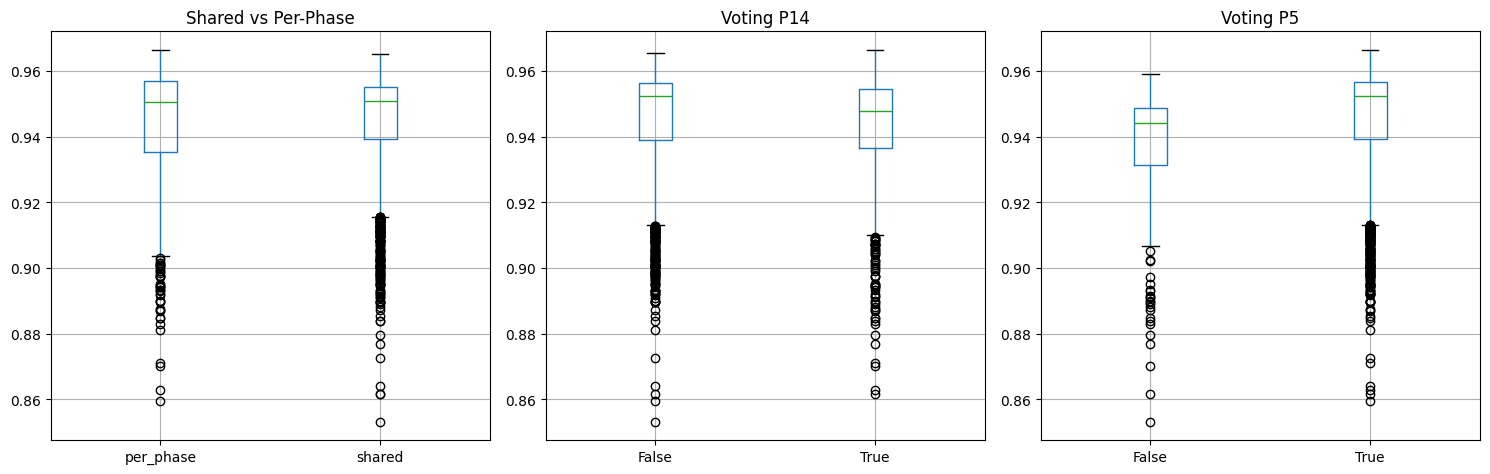

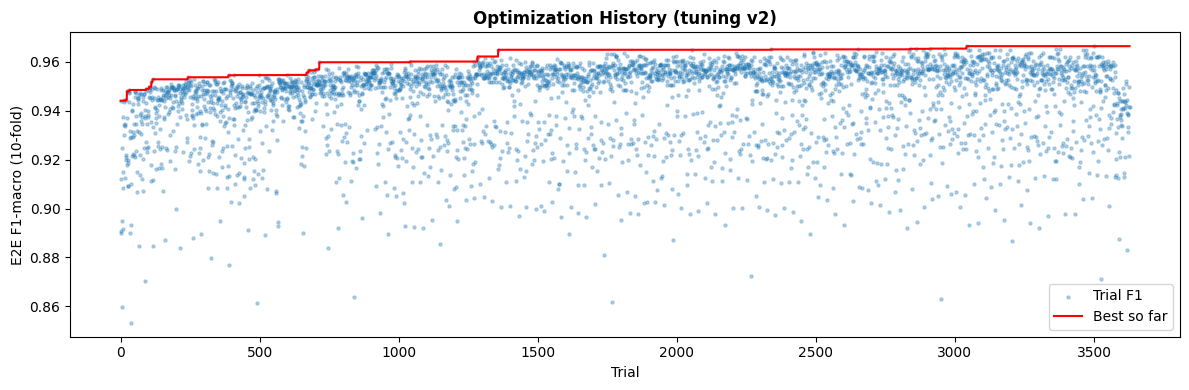


Done, tuning complete.


In [18]:
if all_results:
    import matplotlib.pyplot as plt

    df_a = pd.DataFrame([{
        "f1": r["f1_mean"],
        "p14_mode": r["params"].get("p14_mode"),
        "p14_voting": str(r["params"].get("p14_voting")),
        "p5_voting": str(r["params"].get("p5_voting")),
    } for r in all_results])

    print("\n" + "=" * 60)
    print("  KEY QUESTIONS")
    print("=" * 60)

    print("\n  Q1: Shared vs Per-Phase params?")
    print(df_a.groupby("p14_mode")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n  Q2: Does voting help (phases 1-4)?")
    print(df_a.groupby("p14_voting")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n  Q3: Does voting help (phase 5)?")
    print(df_a.groupby("p5_voting")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n  Q4: Combined mode x voting (phases 1-4)?")
    print(df_a.groupby(["p14_mode", "p14_voting"])["f1"].agg(["mean", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    # ── Plots ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    df_a.boxplot(column="f1", by="p14_mode", ax=axes[0])
    axes[0].set_title("Shared vs Per-Phase"); axes[0].set_xlabel("")

    df_a.boxplot(column="f1", by="p14_voting", ax=axes[1])
    axes[1].set_title("Voting P14"); axes[1].set_xlabel("")

    df_a.boxplot(column="f1", by="p5_voting", ax=axes[2])
    axes[2].set_title("Voting P5"); axes[2].set_xlabel("")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    # Optimization history
    trial_nums = [r["number"] for r in all_results]
    f1_vals = [r["f1_mean"] for r in all_results]
    order = np.argsort(trial_nums)
    t_sorted = np.array(trial_nums)[order]
    f1_sorted = np.array(f1_vals)[order]
    cummax = np.maximum.accumulate(f1_sorted)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(t_sorted, f1_sorted, s=5, alpha=0.3, label="Trial F1")
    ax.plot(t_sorted, cummax, color="red", linewidth=1.5, label="Best so far")
    ax.set_xlabel("Trial"); ax.set_ylabel("E2E F1-macro (10-fold)")
    ax.set_title("Optimization History (tuning v2)", fontweight="bold"); ax.legend()
    plt.tight_layout()
    plt.show()

print("\nDone, tuning complete.")
